# Experiment 1.3.4 — Fixed-count Linear vs stacked-bin multi-$\tau$ SNN

## Scientific question

Experiment 1.3.3 showed that a **250 ms fixed-duration count representation + flattened Linear classifier** is a strong decoder. However, channel-wise counting collapses all spike timing inside each 250 ms window:

\[
z_b[c] = \sum_{t\in b} x_t[c].
\]

This experiment asks:

> **If the same 250 ms bins keep their complete within-bin spike trains, can a feed-forward multi-$\tau$ SNN exploit this fine timing and outperform the fixed-count + Linear baseline?**

The comparison is deliberately structured so that both methods retain the same coarse absolute bin position over the full padded segment.

### Method A — `count_linear`

\[
X\in\mathbb{R}^{T\times30}
\rightarrow
\{X_b\}_{b=1}^{N}
\rightarrow
\left[\sum_t X_1(t),\ldots,\sum_t X_N(t)\right]
\rightarrow
\text{Linear classifier}.
\]

### Method B — `stacked_bin_snn`

Each 250 ms bin contains $L$ original timesteps. Instead of summing over $L$, bins are concatenated along the feature axis:

\[
X_{stack}[\ell] = [X_1[\ell],X_2[\ell],\ldots,X_N[\ell]]
\in\mathbb{R}^{30N},\qquad \ell=1,\ldots,L.
\]

The SNN therefore runs for only $L$ **relative-within-bin timesteps**, while absolute bin identity is encoded by input-channel group. The output neurons are spike-counted over all $L$ steps:

\[
z_k = \sum_{\ell=1}^{L}s^{out}_{\ell,k},\qquad
\mathcal{L}=CE(z,y).
\]

### SNN backbone

\[
30N\rightarrow128\rightarrow128\rightarrow128\rightarrow K
\]

Short-to-multi-$\tau_{syn}$ allocation:

- Layer 1: shifts `(2, 3)`
- Layer 2: shifts `(2, 3, 4, 5)`
- Layer 3: shifts `(2, 3, 4, 5, 6, 7)`
- no recurrence
- all Linear layers use `bias=False`
- whole-segment output spike-count CE

> **Interpretation boundary:** stacked-bin SNN preserves within-bin timing and explicit coarse temporal position, but it does **not** model true sequential dynamics across 250 ms bins. Long-range bin order has been converted into channel identity.

In [43]:
from __future__ import annotations

from pathlib import Path
import copy
import hashlib
import json
import math
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import display

import snntorch as snn
from snntorch import surrogate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the writingRing repository root")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Repository root: /home/ted/project/writingRing
PyTorch: 2.11.0+cu128
CUDA available: True


## 1. Configuration

In [44]:
DATASET_ROOTS = [
    REPO_ROOT / "outputs/action0_wavelets_0e5_1_2_4_8_sr_64" / "low-pass/aligned-board-events/segmentation_padded",
    REPO_ROOT / "outputs/action1_wavelets_0e5_1_2_4_8_sr_64" / "low-pass/aligned-board-events/segmentation_padded",
]

EXPECTED_EVENT_REPRESENTATION = "unsigned"
EXPECTED_EVENT_FEATURE_SCHEMA = "custom_wavelet_polarity_split_abs_events_v1"
EVENT_CHANNEL_COUNT = 30
TOTAL_CHANNEL_COUNT = 36
EXPECTED_SAMPLING_RATE_HZ = 64.0

INCLUDED_LABELS = (
    "A", "B", "C", "D", "E", "X",
    "G", "H", "I", "J", "K", "L",
)

# Match the Phase-B / Phase-C fixed user-disjoint split protocol.
SPLIT_SEED = 12345
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
SEEDS = (11, 23, 101)

BIN_MS = 250.0
HIDDEN_WIDTH = 128
LAYER1_SHIFTS = (2, 3, 4)
LAYER2_SHIFTS = (2, 3, 4)
LAYER3_SHIFTS = (2, 3, 4)

# Keep Phase-C / Experiment-3.0 neuron dynamics fixed.
TAU_MEM_MS = 22.54
TAU_SYN_OUT_MS = 77.47
THRESHOLD = 0.5
SURROGATE_SLOPE = 25.0
RESET_MECHANISM = "subtract"

BATCH_SIZE = 128
NUM_WORKERS = 0
NUM_EPOCHS = 200
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0
GRAD_CLIP_NORM = None
LOGREG_MAX_ITER = 5000

RESUME_EXISTING = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EXPERIMENT_ID = "experiment_1_3_4_count_linear_vs_stacked_bin_snn"
RESULTS_DIR = REPO_ROOT / "notebooks/artifacts" / EXPERIMENT_ID
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Experiment:", EXPERIMENT_ID)
print("Bin duration:", BIN_MS, "ms")
print("SNN seeds:", SEEDS)
print("Fixed split seed:", SPLIT_SEED)
print("Hidden width:", HIDDEN_WIDTH)
print("Layer shifts:", LAYER1_SHIFTS, LAYER2_SHIFTS, LAYER3_SHIFTS)
print("Device:", DEVICE)

Experiment: experiment_1_3_4_count_linear_vs_stacked_bin_snn
Bin duration: 250.0 ms
SNN seeds: (11, 23, 101)
Fixed split seed: 12345
Hidden width: 128
Layer shifts: (2, 3, 4) (2, 3, 4) (2, 3, 4)
Device: cuda


## 2. Reproducibility and $	au$ helpers

In [45]:
def derive_seed(master_seed: int, *parts: object) -> int:
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def shift_to_alpha(shift: int) -> float:
    return float(1.0 - 2.0 ** (-int(shift)))


def alpha_to_tau_ms(alpha: float, sampling_rate_hz: float) -> float:
    dt_ms = 1000.0 / float(sampling_rate_hz)
    return float(-dt_ms / math.log(float(alpha)))


def tau_ms_to_decay(tau_ms: float, sampling_rate_hz: float) -> float:
    dt_ms = 1000.0 / float(sampling_rate_hz)
    return float(math.exp(-dt_ms / float(tau_ms)))


def allocate_neurons(shifts: tuple[int, ...], width: int) -> tuple[int, ...]:
    """Even allocation; for a 2-neuron remainder, place one at each endpoint."""
    base, remainder = divmod(width, len(shifts))
    counts = [base] * len(shifts)
    if remainder == 1:
        counts[0] += 1
    elif remainder == 2:
        counts[0] += 1
        counts[-1] += 1
    else:
        for i in range(remainder):
            counts[i] += 1
    return tuple(counts)


def build_alpha_vector(shifts: tuple[int, ...], width: int) -> torch.Tensor:
    counts = allocate_neurons(shifts, width)
    vals = [shift_to_alpha(s) for s, n in zip(shifts, counts, strict=True) for _ in range(n)]
    assert len(vals) == width
    return torch.tensor(vals, dtype=torch.float32)


seed_everything(SPLIT_SEED)

## 3. Load and validate the same 64 Hz unsigned event cohort

In [46]:
data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=False,
)

rates = sorted({float(m.sampling_rate_hz) for m in data.producer_metadatas})
if len(rates) != 1:
    raise ValueError(f"Roots must share one sampling rate, got {rates}")
SAMPLING_RATE_HZ = rates[0]
if not np.isclose(SAMPLING_RATE_HZ, EXPECTED_SAMPLING_RATE_HZ):
    raise ValueError(f"Expected {EXPECTED_SAMPLING_RATE_HZ} Hz, got {SAMPLING_RATE_HZ}")

for root, metadata in zip(data.padded_roots, data.producer_metadatas, strict=True):
    raw = metadata.raw
    if raw.get("event_representation") != EXPECTED_EVENT_REPRESENTATION:
        raise ValueError(f"{root}: wrong event_representation")
    if raw.get("event_feature_schema") != EXPECTED_EVENT_FEATURE_SCHEMA:
        raise ValueError(f"{root}: wrong event_feature_schema")
    if raw.get("event_channel_count") != EVENT_CHANNEL_COUNT or metadata.channel_count != TOTAL_CHANNEL_COUNT:
        raise ValueError(f"{root}: expected 30 event + 6 IMU channels")

rows = []
keep = set(INCLUDED_LABELS)
for pi, p in enumerate(data.packages):
    if p.padded_spike_imu.shape[2] != TOTAL_CHANNEL_COUNT:
        raise ValueError(f"Unexpected channel count: {p.padded_spike_imu.shape}")
    ev = np.asarray(p.padded_spike_imu[..., :EVENT_CHANNEL_COUNT])
    if np.any(~np.isfinite(ev)) or np.any(ev < 0):
        raise ValueError("Events must be finite and non-negative")
    for si, label in enumerate(p.labels.astype(str)):
        if label not in keep:
            continue
        rows.append(dict(
            package_index=pi,
            segment_index=si,
            user=str(p.user),
            action=str(p.action),
            label=str(label),
            valid_length=int(p.valid_lengths[si]),
            package_padded_length=int(p.padded_spike_imu.shape[1]),
            sample_id=f"{p.user}/action_{p.action}/{si}",
        ))

manifest = pd.DataFrame(rows)
labels_sorted = sorted(manifest.label.unique().tolist())
CLASS_TO_IDX = {lab: i for i, lab in enumerate(labels_sorted)}
IDX_TO_CLASS = {i: lab for lab, i in CLASS_TO_IDX.items()}
manifest["label_idx"] = manifest.label.map(CLASS_TO_IDX).astype(int)
N_CLASSES = len(labels_sorted)
GLOBAL_PADDED_LENGTH = int(manifest.package_padded_length.max())

BIN_STEPS = max(1, int(np.rint(BIN_MS * SAMPLING_RATE_HZ / 1000.0)))
ACTUAL_BIN_MS = BIN_STEPS / SAMPLING_RATE_HZ * 1000.0
N_BINS = int(math.ceil(GLOBAL_PADDED_LENGTH / BIN_STEPS))
STACKED_PADDED_LENGTH = N_BINS * BIN_STEPS
STACKED_INPUT_DIM = N_BINS * EVENT_CHANNEL_COUNT

BETA = tau_ms_to_decay(TAU_MEM_MS, SAMPLING_RATE_HZ)
OUTPUT_ALPHA = tau_ms_to_decay(TAU_SYN_OUT_MS, SAMPLING_RATE_HZ)

print(f"samples={len(manifest)}, users={manifest.user.nunique()}, classes={N_CLASSES}")
print(f"sampling_rate={SAMPLING_RATE_HZ} Hz, global padded length={GLOBAL_PADDED_LENGTH}")
print(f"250 ms implementation: {BIN_STEPS} samples = {ACTUAL_BIN_MS:.3f} ms")
print(f"bins={N_BINS}, padded stacked source steps={STACKED_PADDED_LENGTH}")
print(f"stacked SNN shape per sample: [{BIN_STEPS}, {STACKED_INPUT_DIM}]")
print(f"beta={BETA:.6f}, output_alpha={OUTPUT_ALPHA:.6f}, threshold={THRESHOLD}")

for name, shifts in [("L1", LAYER1_SHIFTS), ("L2", LAYER2_SHIFTS), ("L3", LAYER3_SHIFTS)]:
    counts = allocate_neurons(shifts, HIDDEN_WIDTH)
    desc = [(s, n, alpha_to_tau_ms(shift_to_alpha(s), SAMPLING_RATE_HZ)) for s, n in zip(shifts, counts, strict=True)]
    print(name, "(shift, neurons, tau_syn_ms):", desc)

display(manifest.head())

samples=853, users=20, classes=12
sampling_rate=64.0 Hz, global padded length=256
250 ms implementation: 16 samples = 250.000 ms
bins=16, padded stacked source steps=256
stacked SNN shape per sample: [16, 480]
beta=0.499968, output_alpha=0.817347, threshold=0.5
L1 (shift, neurons, tau_syn_ms): [(2, 43, 54.31342963722199), (3, 42, 117.0136826471659), (4, 43, 242.10347130039656)]
L2 (shift, neurons, tau_syn_ms): [(2, 43, 54.31342963722199), (3, 42, 117.0136826471659), (4, 43, 242.10347130039656)]
L3 (shift, neurons, tau_syn_ms): [(2, 43, 54.31342963722199), (3, 42, 117.0136826471659), (4, 43, 242.10347130039656)]


,package_index,segment_index,user,action,label,valid_length,package_padded_length,sample_id,label_idx
0,0,24,user_0,0,J,72,256,user_0/action_0/24,8
1,0,25,user_0,0,B,128,256,user_0/action_0/25,1
2,0,26,user_0,0,X,106,256,user_0/action_0/26,11
3,0,27,user_0,0,E,122,256,user_0/action_0/27,4
4,0,31,user_0,0,G,124,256,user_0/action_0/31,5


## 4. Fixed user-disjoint split and padding checks

In [47]:
def check_event_padding_is_zero() -> None:
    bad = []
    for r in manifest.itertuples(index=False):
        p = data.packages[int(r.package_index)]
        tail = np.asarray(
            p.padded_spike_imu[int(r.segment_index), int(r.valid_length):, :EVENT_CHANNEL_COUNT]
        )
        mx = float(np.max(np.abs(tail))) if tail.size else 0.0
        if mx > 1e-12:
            bad.append((r.sample_id, mx))
    if bad:
        raise ValueError(f"Non-zero padded event tails found; first examples: {bad[:5]}")
    print("Padding contract verified: padded event tails are zero.")


def make_fixed_user_split(split_seed: int = SPLIT_SEED):
    users = sorted(manifest.user.unique().tolist())
    rng = np.random.default_rng(derive_seed(split_seed, "user_split"))
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)

    n_users = len(perm)
    n_train = int(round(n_users * TRAIN_FRACTION))
    n_val = int(round(n_users * VAL_FRACTION))
    train_users = set(perm[:n_train])
    val_users = set(perm[n_train:n_train + n_val])
    test_users = set(perm[n_train + n_val:])

    train_df = manifest[manifest.user.isin(train_users)].reset_index(drop=True)
    val_df = manifest[manifest.user.isin(val_users)].reset_index(drop=True)
    test_df = manifest[manifest.user.isin(test_users)].reset_index(drop=True)

    assert train_users.isdisjoint(val_users)
    assert train_users.isdisjoint(test_users)
    assert val_users.isdisjoint(test_users)
    return train_df, val_df, test_df, train_users, val_users, test_users


check_event_padding_is_zero()
train_df, val_df, test_df, train_users, val_users, test_users = make_fixed_user_split()

split_table = pd.DataFrame([
    {"split": "train", "users": len(train_users), "samples": len(train_df), "user_ids": ",".join(sorted(train_users))},
    {"split": "val", "users": len(val_users), "samples": len(val_df), "user_ids": ",".join(sorted(val_users))},
    {"split": "test", "users": len(test_users), "samples": len(test_df), "user_ids": ",".join(sorted(test_users))},
])
display(split_table)

Padding contract verified: padded event tails are zero.


,split,users,samples,user_ids
0,train,14,632,"user_0,user_1,user_11,user_12,user_14,user_19,..."
1,val,3,126,"user_15,user_16,user_20"
2,test,3,95,"user_10,user_13,user_18"


## 5. Shared 250 ms representation builders

Both methods start from **exactly the same padded event tensor**. At 64 Hz, 250 ms is 16 samples. The global padded length of 256 therefore gives 16 fixed bins.

For `count_linear`, each `[16,30]` block is summed to `[30]`, producing `[16,30]` before flattening.

For `stacked_bin_snn`, the same source is reshaped to `[16 bins,16 relative steps,30 channels]`, then transposed so the SNN receives:

\[
[16\text{ relative steps},\;16\times30=480\text{ channels}].
\]

No `valid_length` mask is used in either final representation; right-padding is already zero. This makes the comparison use the same full fixed observation window.

In [48]:
def labels_for_df(df: pd.DataFrame) -> np.ndarray:
    return df.label_idx.to_numpy(np.int64)


def build_global_padded_events(df: pd.DataFrame) -> np.ndarray:
    out = np.zeros((len(df), GLOBAL_PADDED_LENGTH, EVENT_CHANNEL_COUNT), np.float32)
    for j, r in enumerate(df.itertuples(index=False)):
        p = data.packages[int(r.package_index)]
        x = np.asarray(
            p.padded_spike_imu[int(r.segment_index), :, :EVENT_CHANNEL_COUNT],
            np.float32,
        )
        out[j, :x.shape[0]] = x
    return out


def pad_to_bin_multiple(X: np.ndarray) -> np.ndarray:
    if X.shape[1] == STACKED_PADDED_LENGTH:
        return X
    pad = STACKED_PADDED_LENGTH - X.shape[1]
    if pad < 0:
        raise ValueError("STACKED_PADDED_LENGTH shorter than input")
    return np.pad(X, ((0, 0), (0, pad), (0, 0)))


def build_count_representation(df: pd.DataFrame):
    X = pad_to_bin_multiple(build_global_padded_events(df))
    B, _, C = X.shape
    # [B, N_bins, bin_steps, C] -> sum within bin -> [B, N_bins, C]
    counts = X.reshape(B, N_BINS, BIN_STEPS, C).sum(axis=2).astype(np.float32)
    return counts, labels_for_df(df)


def build_stacked_bin_representation(df: pd.DataFrame):
    X = pad_to_bin_multiple(build_global_padded_events(df))
    B, _, C = X.shape
    # [B, N_bins, bin_steps, C]
    bins = X.reshape(B, N_BINS, BIN_STEPS, C)
    # Align equal relative positions across all absolute bins:
    # [B, bin_steps, N_bins, C] -> [B, bin_steps, N_bins*C]
    stacked = bins.transpose(0, 2, 1, 3).reshape(B, BIN_STEPS, N_BINS * C).astype(np.float32)
    return stacked, labels_for_df(df)


Xtr_count, ytr = build_count_representation(train_df)
Xva_count, yva = build_count_representation(val_df)
Xte_count, yte = build_count_representation(test_df)

Xtr_stack, _ = build_stacked_bin_representation(train_df)
Xva_stack, _ = build_stacked_bin_representation(val_df)
Xte_stack, _ = build_stacked_bin_representation(test_df)

print("count train:", Xtr_count.shape)
print("stacked SNN train:", Xtr_stack.shape)
assert Xtr_count.shape[1:] == (N_BINS, EVENT_CHANNEL_COUNT)
assert Xtr_stack.shape[1:] == (BIN_STEPS, STACKED_INPUT_DIM)

# Exact information-preservation sanity check for the stacking transform.
reconstructed = Xtr_stack.reshape(len(Xtr_stack), BIN_STEPS, N_BINS, EVENT_CHANNEL_COUNT).transpose(0, 2, 1, 3)
source_binned = pad_to_bin_multiple(build_global_padded_events(train_df)).reshape(len(train_df), N_BINS, BIN_STEPS, EVENT_CHANNEL_COUNT)
np.testing.assert_allclose(reconstructed, source_binned)
print("Stacking transform verified: no within-bin spike samples are lost.")

count train: (632, 16, 30)
stacked SNN train: (632, 16, 480)
Stacking transform verified: no within-bin spike samples are lost.


## 6. Baseline — 250 ms count + flattened Linear

In [49]:
def classification_metrics(y_true, y_pred):
    return dict(
        accuracy=float(accuracy_score(y_true, y_pred)),
        balanced_accuracy=float(balanced_accuracy_score(y_true, y_pred)),
        macro_f1=float(f1_score(y_true, y_pred, average="macro")),
    )


def fit_count_linear(Xtr, ytr, Xva, yva, Xte, yte):
    A = Xtr.reshape(len(Xtr), -1)
    B = Xva.reshape(len(Xva), -1)
    C = Xte.reshape(len(Xte), -1)

    # Match Experiment 1.3.3: train-only feature standardization before Logistic Regression.
    scaler = StandardScaler()
    A = scaler.fit_transform(A)
    B = scaler.transform(B)
    C = scaler.transform(C)

    model = LogisticRegression(
        max_iter=LOGREG_MAX_ITER,
        random_state=derive_seed(SPLIT_SEED, "count_linear"),
        solver="lbfgs",
    )
    model.fit(A, ytr)

    out = {}
    for split_name, X, y in [("train", A, ytr), ("val", B, yva), ("test", C, yte)]:
        pred = model.predict(X)
        out[split_name] = classification_metrics(y, pred) | {
            "y_true": np.asarray(y),
            "y_pred": np.asarray(pred),
        }
    return model, scaler, out


linear_model, linear_scaler, linear_eval = fit_count_linear(
    Xtr_count, ytr, Xva_count, yva, Xte_count, yte
)

pd.DataFrame([
    {"method": "count_linear", "split": split_name, **{k: v for k, v in vals.items() if not k.startswith("y_")}}
    for split_name, vals in linear_eval.items()
])

,method,split,accuracy,balanced_accuracy,macro_f1
0,count_linear,train,1.000000,1.000000,1.000000
1,count_linear,val,0.714286,0.707705,0.706672
2,count_linear,test,0.547368,0.556217,0.548821


## 7. Three-layer short-to-multi-$	au$ stacked-bin SNN

In [50]:
class StackedBinMultiTauSNN(nn.Module):
    """3-layer feed-forward heterogeneous multi-tau_syn Synaptic-LIF network."""

    def __init__(self, input_channels: int, num_classes: int):
        super().__init__()
        spike_grad = surrogate.fast_sigmoid(slope=SURROGATE_SLOPE)

        self.fc1 = nn.Linear(input_channels, HIDDEN_WIDTH, bias=False)
        self.lif1 = snn.Synaptic(
            alpha=build_alpha_vector(LAYER1_SHIFTS, HIDDEN_WIDTH),
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            reset_mechanism=RESET_MECHANISM,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
        )

        self.fc2 = nn.Linear(HIDDEN_WIDTH, HIDDEN_WIDTH, bias=False)
        self.lif2 = snn.Synaptic(
            alpha=build_alpha_vector(LAYER2_SHIFTS, HIDDEN_WIDTH),
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            reset_mechanism=RESET_MECHANISM,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
        )

        self.fc3 = nn.Linear(HIDDEN_WIDTH, HIDDEN_WIDTH, bias=False)
        self.lif3 = snn.Synaptic(
            alpha=build_alpha_vector(LAYER3_SHIFTS, HIDDEN_WIDTH),
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            reset_mechanism=RESET_MECHANISM,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
        )

        self.fc_out = nn.Linear(HIDDEN_WIDTH, num_classes, bias=False)
        self.lif_out = snn.Synaptic(
            alpha=OUTPUT_ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            reset_mechanism=RESET_MECHANISM,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
        )

    def forward(self, x: torch.Tensor, return_hidden: bool = False):
        """x: [B, relative_time=BIN_STEPS, N_BINS*30]."""
        batch_size = x.shape[0]
        device = x.device

        syn1 = torch.zeros(batch_size, HIDDEN_WIDTH, device=device)
        mem1 = torch.zeros_like(syn1)
        syn2 = torch.zeros(batch_size, HIDDEN_WIDTH, device=device)
        mem2 = torch.zeros_like(syn2)
        syn3 = torch.zeros(batch_size, HIDDEN_WIDTH, device=device)
        mem3 = torch.zeros_like(syn3)
        syn_out = torch.zeros(batch_size, N_CLASSES, device=device)
        mem_out = torch.zeros_like(syn_out)

        out_spikes = []
        if return_hidden:
            h1_spikes, h2_spikes, h3_spikes = [], [], []

        for t in range(x.shape[1]):
            cur1 = self.fc1(x[:, t])
            spk1, syn1, mem1 = self.lif1(cur1, syn1, mem1)

            cur2 = self.fc2(spk1)
            spk2, syn2, mem2 = self.lif2(cur2, syn2, mem2)

            cur3 = self.fc3(spk2)
            spk3, syn3, mem3 = self.lif3(cur3, syn3, mem3)

            cur_out = self.fc_out(spk3)
            spk_out, syn_out, mem_out = self.lif_out(cur_out, syn_out, mem_out)
            out_spikes.append(spk_out)

            if return_hidden:
                h1_spikes.append(spk1)
                h2_spikes.append(spk2)
                h3_spikes.append(spk3)

        out = torch.stack(out_spikes, dim=1)
        if not return_hidden:
            return out
        return out, (
            torch.stack(h1_spikes, dim=1),
            torch.stack(h2_spikes, dim=1),
            torch.stack(h3_spikes, dim=1),
        )


probe = StackedBinMultiTauSNN(STACKED_INPUT_DIM, N_CLASSES)
print(probe)
print("Trainable parameters:", sum(p.numel() for p in probe.parameters() if p.requires_grad))

StackedBinMultiTauSNN(
  (fc1): Linear(in_features=480, out_features=128, bias=False)
  (lif1): Synaptic()
  (fc2): Linear(in_features=128, out_features=128, bias=False)
  (lif2): Synaptic()
  (fc3): Linear(in_features=128, out_features=128, bias=False)
  (lif3): Synaptic()
  (fc_out): Linear(in_features=128, out_features=12, bias=False)
  (lif_out): Synaptic()
)
Trainable parameters: 95744


## 8. Whole-segment spike-count objective and training helpers

For every stacked sample, all output spikes across the 16 relative timesteps are counted:

\[
\text{logits} = \sum_{\ell=1}^{16}s^{out}_\ell.
\]

This is intentionally different from `timestep_ce` and `relative_10bin_ce`: the **coarse 16-bin segment position is already encoded in the 480 input channels**, so the SNN objective only asks the short temporal processor to transform the preserved within-bin timing into a gesture decision.

In [51]:
class ArrayDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_loader(X, y, batch_size, shuffle, seed):
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(
        ArrayDataset(X, y),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_init_fn if NUM_WORKERS else None,
        generator=g,
    )


def whole_count_logits(out_spikes: torch.Tensor) -> torch.Tensor:
    return out_spikes.sum(dim=1)


@torch.no_grad()
def evaluate_snn(model, loader):
    model.eval()
    losses, y_true, y_pred = [], [], []
    firing_sum = np.zeros(4, dtype=np.float64)
    firing_den = np.zeros(4, dtype=np.float64)

    for X, y in loader:
        X = X.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        out, hidden = model(X, return_hidden=True)
        logits = whole_count_logits(out)
        loss = F.cross_entropy(logits, y)
        losses.append(float(loss.item()) * len(y))

        pred = logits.argmax(dim=1)
        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(pred.cpu().numpy().tolist())

        tensors = (*hidden, out)
        for i, s in enumerate(tensors):
            firing_sum[i] += float(s.sum().item())
            firing_den[i] += float(s.numel())

    m = classification_metrics(y_true, y_pred)
    m["loss"] = sum(losses) / max(1, len(y_true))
    m["l1_fr"] = firing_sum[0] / firing_den[0]
    m["l2_fr"] = firing_sum[1] / firing_den[1]
    m["l3_fr"] = firing_sum[2] / firing_den[2]
    m["out_fr"] = firing_sum[3] / firing_den[3]
    m["y_true"] = np.asarray(y_true)
    m["y_pred"] = np.asarray(y_pred)
    return m


def checkpoint_path(seed: int) -> Path:
    return RESULTS_DIR / f"stacked_bin_snn_seed_{seed}.pt"


def train_one_seed(seed: int):
    ckpt = checkpoint_path(seed)
    if RESUME_EXISTING and ckpt.exists():
        payload = torch.load(ckpt, map_location="cpu", weights_only=False)
        required = {
            "bin_ms": BIN_MS,
            "bin_steps": BIN_STEPS,
            "n_bins": N_BINS,
            "input_dim": STACKED_INPUT_DIM,
            "hidden_width": HIDDEN_WIDTH,
            "layer1_shifts": LAYER1_SHIFTS,
            "layer2_shifts": LAYER2_SHIFTS,
            "layer3_shifts": LAYER3_SHIFTS,
            "split_seed": SPLIT_SEED,
        }
        if all(payload.get(k) == v for k, v in required.items()):
            print(f"Seed {seed}: loading completed checkpoint {ckpt.name}")
            return payload
        raise ValueError(f"Checkpoint configuration mismatch: {ckpt}")

    seed_everything(seed)
    model = StackedBinMultiTauSNN(STACKED_INPUT_DIM, N_CLASSES).to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )

    train_loader = make_loader(
        Xtr_stack, ytr, BATCH_SIZE, True, derive_seed(seed, "train_loader")
    )
    train_eval_loader = make_loader(
        Xtr_stack, ytr, BATCH_SIZE, False, derive_seed(seed, "train_eval")
    )
    val_loader = make_loader(
        Xva_stack, yva, BATCH_SIZE, False, derive_seed(seed, "val")
    )
    test_loader = make_loader(
        Xte_stack, yte, BATCH_SIZE, False, derive_seed(seed, "test")
    )

    best_state = None
    best_epoch = None
    best_val_ba = -np.inf
    best_val_loss = np.inf
    history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        batch_losses = []
        for X, y in train_loader:
            X = X.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            out = model(X)
            logits = whole_count_logits(out)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            if GRAD_CLIP_NORM is not None:
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()
            batch_losses.append(float(loss.item()) * len(y))

        train_m = evaluate_snn(model, train_eval_loader)
        val_m = evaluate_snn(model, val_loader)
        history.append({
            "epoch": epoch,
            "optimization_loss": sum(batch_losses) / len(train_df),
            **{f"train_{k}": v for k, v in train_m.items() if not k.startswith("y_")},
            **{f"val_{k}": v for k, v in val_m.items() if not k.startswith("y_")},
        })

        improved = (
            val_m["balanced_accuracy"] > best_val_ba
            or (
                np.isclose(val_m["balanced_accuracy"], best_val_ba)
                and val_m["loss"] < best_val_loss
            )
        )
        if improved:
            best_val_ba = val_m["balanced_accuracy"]
            best_val_loss = val_m["loss"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % 10 == 0 or epoch == NUM_EPOCHS:
            print(
                f"seed={seed} epoch={epoch:3d} | "
                f"train BA={train_m['balanced_accuracy']:.4f} | "
                f"val BA={val_m['balanced_accuracy']:.4f} | "
                f"L1/L2/L3/out FR={val_m['l1_fr']:.4f}/"
                f"{val_m['l2_fr']:.4f}/{val_m['l3_fr']:.4f}/{val_m['out_fr']:.4f}"
            )

    model.load_state_dict(best_state)
    train_best = evaluate_snn(model, train_eval_loader)
    val_best = evaluate_snn(model, val_loader)
    test_best = evaluate_snn(model, test_loader)

    payload = {
        "seed": seed,
        "split_seed": SPLIT_SEED,
        "bin_ms": BIN_MS,
        "bin_steps": BIN_STEPS,
        "n_bins": N_BINS,
        "input_dim": STACKED_INPUT_DIM,
        "hidden_width": HIDDEN_WIDTH,
        "layer1_shifts": LAYER1_SHIFTS,
        "layer2_shifts": LAYER2_SHIFTS,
        "layer3_shifts": LAYER3_SHIFTS,
        "best_epoch": best_epoch,
        "history": history,
        "train": train_best,
        "val": val_best,
        "test": test_best,
        "model_state_dict": {k: v.cpu() for k, v in best_state.items()},
    }
    torch.save(payload, ckpt)
    return payload

## 9. Run the three paired SNN training seeds

In [52]:
runs = []
for seed in SEEDS:
    print("=" * 100)
    runs.append(train_one_seed(seed))

print("Completed SNN runs:", len(runs))

seed=11 epoch=  1 | train BA=0.0833 | val BA=0.0833 | L1/L2/L3/out FR=0.0000/0.0000/0.0000/0.0000
seed=11 epoch= 10 | train BA=0.1105 | val BA=0.1000 | L1/L2/L3/out FR=0.0008/0.0007/0.0009/0.0005
seed=11 epoch= 20 | train BA=0.2020 | val BA=0.1287 | L1/L2/L3/out FR=0.0033/0.0051/0.0084/0.0045
seed=11 epoch= 30 | train BA=0.3199 | val BA=0.1431 | L1/L2/L3/out FR=0.0051/0.0079/0.0117/0.0048
seed=11 epoch= 40 | train BA=0.4574 | val BA=0.2299 | L1/L2/L3/out FR=0.0087/0.0159/0.0233/0.0102
seed=11 epoch= 50 | train BA=0.5761 | val BA=0.3382 | L1/L2/L3/out FR=0.0126/0.0269/0.0405/0.0155
seed=11 epoch= 60 | train BA=0.6409 | val BA=0.3750 | L1/L2/L3/out FR=0.0162/0.0310/0.0451/0.0248
seed=11 epoch= 70 | train BA=0.7259 | val BA=0.3400 | L1/L2/L3/out FR=0.0190/0.0385/0.0571/0.0233
seed=11 epoch= 80 | train BA=0.7878 | val BA=0.4118 | L1/L2/L3/out FR=0.0238/0.0530/0.0676/0.0312
seed=11 epoch= 90 | train BA=0.8432 | val BA=0.4414 | L1/L2/L3/out FR=0.0273/0.0570/0.0776/0.0330
seed=11 epoch=100 | 

## 10. Comparison table

In [53]:
rows = []

# Linear is deterministic for this fixed split, so report it once.
for split_name in ("train", "val", "test"):
    m = linear_eval[split_name]
    rows.append({
        "method": "count_linear",
        "seed": np.nan,
        "split": split_name,
        "best_epoch": np.nan,
        "accuracy": m["accuracy"],
        "balanced_accuracy": m["balanced_accuracy"],
        "macro_f1": m["macro_f1"],
        "l1_fr": np.nan,
        "l2_fr": np.nan,
        "l3_fr": np.nan,
        "out_fr": np.nan,
    })

for run in runs:
    for split_name in ("train", "val", "test"):
        m = run[split_name]
        rows.append({
            "method": "stacked_bin_snn",
            "seed": run["seed"],
            "split": split_name,
            "best_epoch": run["best_epoch"],
            "accuracy": m["accuracy"],
            "balanced_accuracy": m["balanced_accuracy"],
            "macro_f1": m["macro_f1"],
            "l1_fr": m["l1_fr"],
            "l2_fr": m["l2_fr"],
            "l3_fr": m["l3_fr"],
            "out_fr": m["out_fr"],
        })

results_df = pd.DataFrame(rows)
results_df.to_csv(RESULTS_DIR / "results.csv", index=False)
display(results_df)

snn_test = results_df.query("method == 'stacked_bin_snn' and split == 'test'")
summary = pd.DataFrame([
    {
        "method": "count_linear",
        "n_runs": 1,
        "test_BA_mean": linear_eval["test"]["balanced_accuracy"],
        "test_BA_sd": np.nan,
        "test_accuracy_mean": linear_eval["test"]["accuracy"],
        "test_macro_f1_mean": linear_eval["test"]["macro_f1"],
    },
    {
        "method": "stacked_bin_snn",
        "n_runs": len(snn_test),
        "test_BA_mean": snn_test.balanced_accuracy.mean(),
        "test_BA_sd": snn_test.balanced_accuracy.std(ddof=1),
        "test_accuracy_mean": snn_test.accuracy.mean(),
        "test_macro_f1_mean": snn_test.macro_f1.mean(),
    },
])
summary.to_csv(RESULTS_DIR / "summary.csv", index=False)
display(summary)

,method,seed,split,best_epoch,accuracy,balanced_accuracy,macro_f1,l1_fr,l2_fr,l3_fr,out_fr
0,count_linear,NaN,train,NaN,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN
1,count_linear,NaN,val,NaN,0.714286,0.707705,0.706672,NaN,NaN,NaN,NaN
2,count_linear,NaN,test,NaN,0.547368,0.556217,0.548821,NaN,NaN,NaN,NaN
3,stacked_bin_snn,11.0,train,163.0,0.968354,0.968227,0.968743,0.043826,0.088200,0.130244,0.049405
4,stacked_bin_snn,11.0,val,163.0,0.626984,0.621131,0.613169,0.035753,0.074982,0.111964,0.048694
5,stacked_bin_snn,11.0,test,163.0,0.515789,0.522817,0.516764,0.052806,0.093431,0.131661,0.051206
6,stacked_bin_snn,23.0,train,178.0,0.963608,0.963306,0.964530,0.043237,0.109651,0.151601,0.048202
7,stacked_bin_snn,23.0,val,178.0,0.595238,0.605820,0.582898,0.035594,0.094436,0.131189,0.044478
8,stacked_bin_snn,23.0,test,178.0,0.473684,0.501984,0.466830,0.054492,0.123679,0.152184,0.048410
9,stacked_bin_snn,101.0,train,132.0,0.943038,0.943358,0.945316,0.038552,0.091635,0.151896,0.049487


,method,n_runs,test_BA_mean,test_BA_sd,test_accuracy_mean,test_macro_f1_mean
0,count_linear,1,0.556217,NaN,0.547368,0.548821
1,stacked_bin_snn,3,0.483851,0.050534,0.466667,0.459538


## 11. Validation BA vs epoch and final test comparison

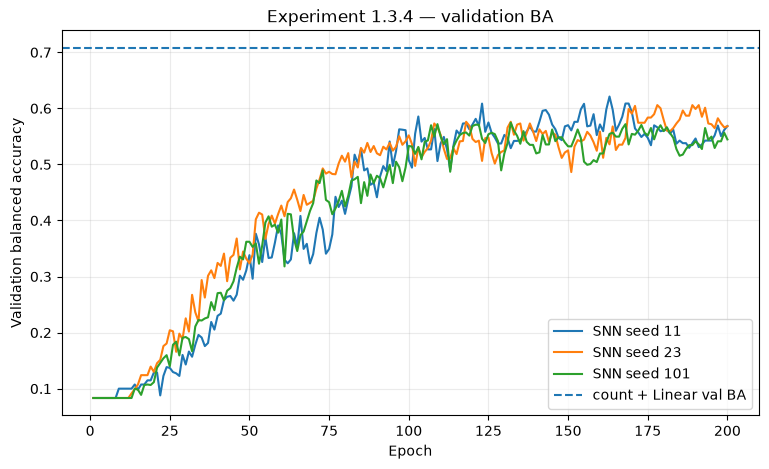

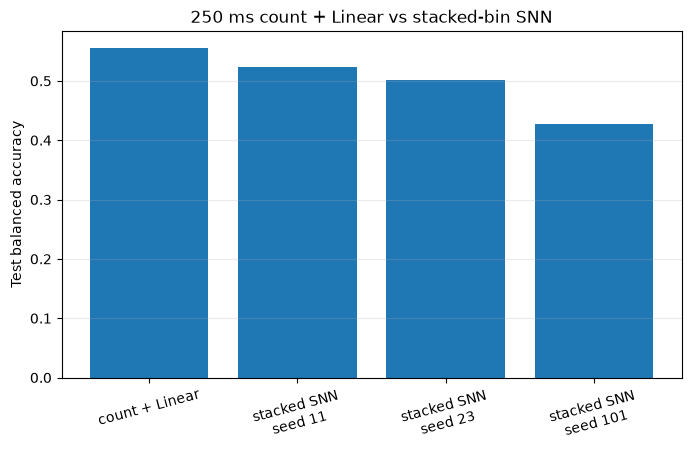

In [54]:
plt.figure(figsize=(9, 5))
for run in runs:
    h = pd.DataFrame(run["history"])
    plt.plot(h.epoch, h.val_balanced_accuracy, label=f"SNN seed {run['seed']}")
plt.axhline(
    linear_eval["val"]["balanced_accuracy"],
    linestyle="--",
    label="count + Linear val BA",
)
plt.xlabel("Epoch")
plt.ylabel("Validation balanced accuracy")
plt.title("Experiment 1.3.4 — validation BA")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

plot_df = pd.DataFrame({
    "method": ["count + Linear", *[f"stacked SNN\nseed {r['seed']}" for r in runs]],
    "test_BA": [linear_eval["test"]["balanced_accuracy"], *[r["test"]["balanced_accuracy"] for r in runs]],
})
plt.figure(figsize=(8, 4.5))
plt.bar(plot_df.method, plot_df.test_BA)
plt.ylabel("Test balanced accuracy")
plt.title("250 ms count + Linear vs stacked-bin SNN")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
plt.show()

## 12. Interpretation guide

This experiment is designed to isolate one specific representational difference:

| Property | Count + Linear | Stacked-bin SNN |
|---|---:|---:|
| Same 250 ms boundaries | Yes | Yes |
| Same coarse absolute bin position | Yes | Yes, encoded by channel group |
| Preserves exact spike sample within each 250 ms bin | **No** | **Yes** |
| Nonlinear temporal transformation inside 250 ms | No | **Yes** |
| True recurrent/continuous state across different 250 ms bins | No | **No** |

### Primary comparison

If `stacked_bin_snn > count_linear`, the result supports:

> Keeping within-bin spike timing and processing it with SNN dynamics provides useful discriminative information beyond 250 ms channel counts.

It should **not** be interpreted as proof that the model learned long-term recurrent memory, because absolute bins are presented simultaneously as distinct channel groups.

### If the SNN does not beat Linear

That result is also informative. It would suggest that, at this 250 ms scale, most task-relevant information is already captured by channel counts plus coarse temporal position, or that the current SNN readout/training is not yet extracting the residual fine-timing information effectively.

### Follow-up control if needed

A stronger attribution test would compare this model against a capacity-matched non-spiking temporal MLP/Conv model on the exact `[16,480]` stacked input. That would separate the value of preserved spike timing from the value of SNN-specific dynamics.